## Ugropy power users

In this final section of the tutorial we will explore some advanced features of
`ugropy` that are not covered in the previous sections. These features are
intended for users who want to customize the behavior of the already
implemented models in `ugropy` or who wants to implement their own models.

### Non-optimal solutions

As explained in previous sections,`ugropy` allows you to search multiple
solutions for the models, but all these solutions are optimal (uses the same
number of groups to represent the molecule). It's possible to search for
non-optimal solutions along with the optimal ones. This is useful when the user
wants to find all possible combinations of fragments that cover the molecule.
This feature is intended for research purposes and is not recommended to
actually model the molecules.

We can do this for all the `ugropy` models with the `search_nonoptimal`
parameter:

In [2]:
from ugropy import unifac

solutions = unifac.get_groups(
    "9,10-dihydroanthracene",
    search_multiple_solutions=True, # If this is False, search_nonoptimal is ignored
    search_nonoptimal=True,
)

# Three solutions are found:
solutions

We can check all the obtained solutions:

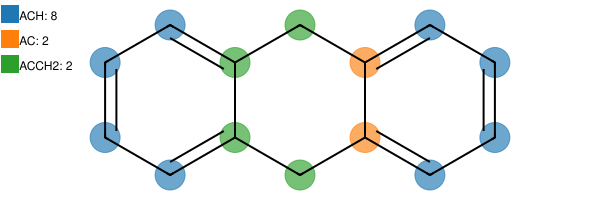

In [3]:
solutions[0].draw(width=600)

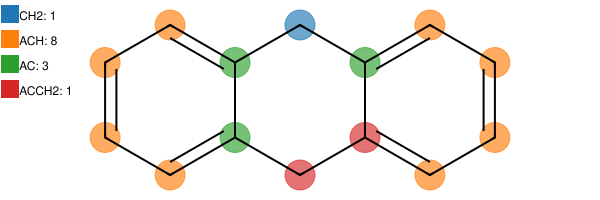

In [4]:
solutions[1].draw(width=600)

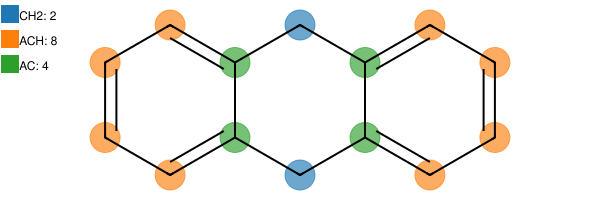

In [5]:
solutions[2].draw(width=600)

If you are an experienced user of UNIFAC-like models, you may notice that the
only "correct" solution is the first one. When non-optimal solutions are
searched, the algorithm always will find the optimal solutions first, and then
it will search for non-optimal solutions in a "non-optimal" order.

### Changing the default ILP solver

By default, `ugropy` uses the default CBC solver from the `PulP` library. But
`PulP` supports a lot of different solvers. Changing the ILP solver has impact
on the execution time of the library. An example could be the `XPRESS_PY`
solver.

First, you must install `XPRESS` with:

```shell
pip install xpress
```

Then you can change the default solver with a simple argument:

/home/salvador/.virtualenvs/ugropy/lib/python3.12/site-packages/pulp/apis/xpress_api.py:751: LicenseWarning: Using the Community license in this session. If you have a full Xpress license, pass the full path to your license file to xpress.init(). If you want to use the FICO Community license and no longer want to see this message, use the following code before using the xpress module:
  xpress.init('/home/salvador/.virtualenvs/ugropy/lib/python3.12/site-packages/xpresslibs/bin/community-xpauth.xpr')
  model = xpress.problem()
/home/salvador/.virtualenvs/ugropy/lib/python3.12/site-packages/pulp/apis/xpress_api.py:774: DeprecationWarning: Deprecated in Xpress 9.8: use problem.addCols instead.
  model.addcols(obj, [0] * (len(obj) + 1), [], [], lb, ub, names, ctype)


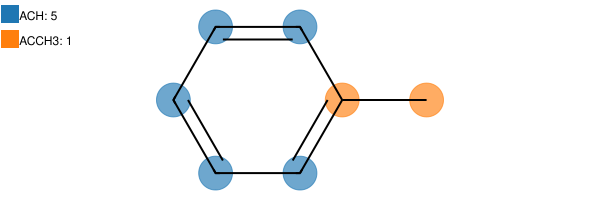

In [6]:
from ugropy import unifac


unifac.get_groups("toluene", solver_arguments={"solver": "XPRESS_PY"}).draw(width=600)

### Models classes and attributes

`ugropy` is designed with a singleton pattern, so all the models that we were
using in the tutorial are instances of the `FragmentationModel` class. This
class has some attributes that can be used for some purposes and to check the
models' information and definition.

Each model of `ugropy` is formed by two different classes, the
`FragmentationModel` and the `FragmentationResult` classes.

The `FragmentationModel` class is the one that contains all the information
about the model, like the fragments definitions. Is the base class to define a
minimum model and has the `get_groups` method. All the models in `ugropy` are
not a direct instance of this base class, but instances of subclasses that
inherit from it. For example, the UNIFAC model is an instance of the
`GibbsModel` class (a child of `FragmentationModel`). The differences between
these classes are that some different methods are available on the subclasses
(for example the filters of multiple solutions). Also, a `GibbsModel` requires
more information about the fragments, like the R and Q values, to be
instantiated.

Finally, each `FragmentationModel` class, return its specific
`FragmentationResult` class instance when the `get_groups` method is called. In
the case of a `GibbsModel`, the `get_groups` method returns a
`GibbsFragmentationResult` class instance (a child of `FragmentationResult`).
This is designed this way because some models do additional things after
obtaining the fragments. For example, the `GibbsFragmentationResult` class
calculates the $R$ and $Q$ values from the solution. The
`JobackFragmentationResult` class calculates the Joback properties from the
solution.

All this explanation is important in terms of understand that all the models
has the same attributes and methods required by the `FragmentationModel` base
class, but also there are others that are specific to the subclasses.

In [ ]:
from ugropy import unifac, psrk, dortmund


unifac.subgroups_info

,subgroup_number,main_group,R,Q
group,,,,
CH3,1,1,0.9011,0.848
CH2,2,1,0.6744,0.540
CH,3,1,0.4469,0.228
C,4,1,0.2195,0.000
CH2=CH,5,2,1.3454,1.176
...,...,...,...,...
NCO,109,51,1.0567,0.732
(CH2)2SU,118,55,2.6869,2.120
CH2CHSU,119,55,2.4595,1.808


Moreover, you can consult the fragments properties contributions of models
like Joback:

In [ ]:
from ugropy import joback, abdulelah_gani

joback.properties_contributions

,Tc,Pc,Vc,Tb,Tf,Hform,Gform,a,b,c,d,Hfusion,Hvap,na,nb,num_of_atoms
group,,,,,,,,,,,,,,,,
-CH3,0.0141,-0.0012,65.0,23.58,-5.10,-76.45,-43.96,19.500,-0.00808,0.000153,-9.670000e-08,0.908,2.373,548.29,-1.719,4
-CH2-,0.0189,0.0000,56.0,22.88,11.27,-20.64,8.42,-0.909,0.09500,-0.000054,1.190000e-08,2.590,2.226,94.16,-0.199,3
>CH-,0.0164,0.0020,41.0,21.74,12.64,29.89,58.36,-23.000,0.20400,-0.000265,1.200000e-07,0.749,1.691,-322.15,1.187,2
>C<,0.0067,0.0043,27.0,18.25,46.43,82.23,116.02,-66.200,0.42700,-0.000641,3.010000e-07,-1.460,0.636,-573.56,2.307,1
=CH2,0.0113,-0.0028,56.0,18.18,-4.32,-9.63,3.77,23.600,-0.03810,0.000172,-1.030000e-07,-0.473,1.724,495.01,-1.539,3
=CH-,0.0129,-0.0006,46.0,24.96,8.73,37.97,48.53,-8.000,0.10500,-0.000096,3.560000e-08,2.691,2.205,82.28,-0.242,2
=C<,0.0117,0.0011,38.0,24.14,11.14,83.99,92.36,-28.100,0.20800,-0.000306,1.460000e-07,3.063,2.138,NaN,NaN,1
=C=,0.0026,0.0028,36.0,26.15,17.78,142.14,136.70,27.400,-0.05570,0.000101,-5.020000e-08,4.720,2.661,NaN,NaN,1
CH,0.0027,-0.0008,46.0,9.20,-11.18,79.30,77.71,24.500,-0.02710,0.000111,-6.780000e-08,2.322,1.155,NaN,NaN,2


From all fragmentation models you have all the RDKit mol objects of each 
fragment already instantiated on a dictionary. This could be helpful to
for calculations, multiple solution filtering, or visualization:

In [ ]:
unifac.detection_mols["CH3"]

In [ ]:
unifac.detection_mols["CH2O"].GetNumAtoms()

2

### Changing the fragments representation of models

aasdasd

### SMARTS tutorial


TODO

### User defined fragmentation models

Users may use the `ugropy` API to define their own fragmentation models. The
basic models API is the `FragmentationModel` class. Instances of this class
have all the methods and attributes necessary to define a fragmentation model.

In [ ]:
from ugropy import FragmentationModel

Groups are defined on a `pandas` DataFrame. This is because is convenient
to store the data in a tabular format, and simply read it from a file. You can
check examples on the repository (https://github.com/ipqa-research/ugropy/blob/main/ugropy/groupscsv/unifac/unifac_subgroups.csv)

We can define a simplified UNIFAC fragmentation model as follows:

In [ ]:
import pandas as pd

# We define a simple fragmentation model with some common groups.
df = pd.DataFrame(
    {
        "group": ["CH3", "CH2", "CH", "C", "AC", "ACH", "ACCH3", "ACCH2"],
        "smarts": [
            "[CX4H3]",
            "[CX4H2]",
            "[CX4H]",
            "[CX4H0]",
            "[cH0]",
            "[cH]",
            "[cH0][CX4H3]",
            "[cH0][CX4H2]",
        ]
    }
)

# Set the group column as the index
df.set_index("group", inplace=True)


# Define a fragmentation model using the defined groups. UNIFAC-like models
# doesn't allow overlappin groups or atoms that not belong to any group.
mymodel = FragmentationModel(
    subgroups=df,
    allow_overlapping=False,
    allow_free_atoms=False, 
)

With this instance we can detect fragments and solve groups as any other
`ugropy` model. For example:

In [ ]:
sol = mymodel.get_groups("toluene")

sol.subgroups

{'ACH': 5, 'ACCH3': 1}

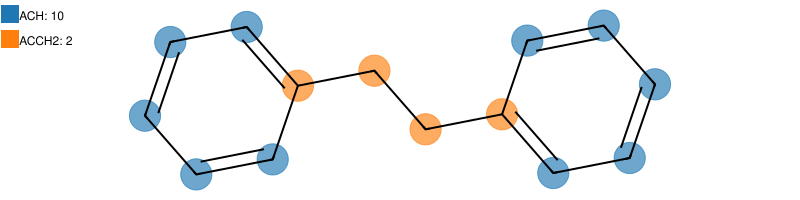

In [ ]:
sol = mymodel.get_groups("bibenzyl")

sol.draw(width=800)


The `FragmentationModel.get_groups` method returns a `FragmentationResult`
object. To extend the behavior of the base `FragmentationModel` class, you can
inherit from it and inherit from `FragmentationResult` as well.

An example, could be the `GibbsModel` class and the `GibbsFragmentationResult`
class. The differences between these classes are that receives an extra argument
(the groups' information dataframe). These models work exactly the same but
also calculates the R and Q of the molecule once the fragments are detected.



In [ ]:
from ugropy import GibbsFragmentationResult, GibbsModel

You may check these classes source code in the API documentation, it's very
simple to follow and understand how to extend the basic behavior of the base
``FragmentationModel`` class.
